# Heart Failure Risk Prediction MLOps Pipeline

---

# ETAPA 1: Preprocesamiento y detección de Data Leakage

## 1. Introducción y Contexto del Proyecto

### 1.1. Definición del Problema
El presente proyecto aborda el desafío de la clasificación supervisada en el ámbito de la salud, específicamente en la predicción del riesgo de enfermedad cardíaca. El objetivo principal es construir un modelo capaz de identificar si un paciente presenta riesgo de falla cardíaca (HeartDisease = 1) o no (HeartDisease = 0), a partir de variables clínicas como edad, presión arterial, colesterol y otros indicadores relevantes.

Más allá del desarrollo de un modelo predictivo, este trabajo se enfoca en la implementación de un flujo completo de Machine Learning bajo principios de MLOps. Esto incluye desde el análisis exploratorio y preprocesamiento de datos, hasta el entrenamiento, validación, despliegue y monitoreo del modelo en un entorno controlado.

> **Importancia del Problema:** Las enfermedades cardiovasculares representan una de las principales causas de muerte a nivel mundial. La detección temprana del riesgo permite tomar decisiones clínicas oportunas, reducir complicaciones y mejorar la calidad de vida de los pacientes. En este contexto, minimizar los falsos negativos (pacientes en riesgo no detectados) es crítico, ya que estos casos pueden derivar en consecuencias graves si no son identificados a tiempo.

### 1.2. Descripción del Conjunto de Datos

## 2. Exploración de datos (EDA)

Esta sección corresponde a la fase de análisis exploratorio y preparación de datos, la cual constituye un paso crítico para garantizar la validez del modelo predictivo y evitar errores metodológicos como el *data leakage*. El análisis se estructura en torno a tres objetivos fundamentales:

1. **Evaluar la calidad e integridad del dataset:** Se realiza una auditoría inicial de los datos para identificar valores faltantes, verificar la consistencia de tipos de variables y analizar la distribución de la variable objetivo (`HeartDisease`). Este paso permite detectar posibles problemas de desbalance de clases y asegurar la confiabilidad de la información antes del modelado.

2. **Detección y prevención de Data Leakage:** Se analiza el flujo de transformación de los datos para identificar posibles fuentes de fuga de información que puedan inflar artificialmente el desempeño del modelo. En particular, se evalúa el impacto de aplicar transformaciones (como escalamiento) antes de la partición de los datos, y se establece el uso de *pipelines* como mecanismo para garantizar que todas las transformaciones se ajusten exclusivamente sobre el conjunto de entrenamiento.

3. **Preparación de datos para modelado robusto:** Se define un flujo estructurado de procesamiento y modelado en el que las transformaciones de los datos y el modelo se integran dentro de una misma secuencia. Sobre esta estructura, se implementa la optimización de hiperparámetros mediante `GridSearchCV` con validación cruzada, garantizando que cada transformación sea ajustada exclusivamente sobre los datos de entrenamiento en cada partición. Este enfoque evita la fuga de información, mantiene la coherencia del proceso de entrenamiento y contribuye a una estimación más realista del desempeño del modelo.


### 2.1 Carga de Datos 

In [14]:
import pandas as pd
from IPython.display import display, HTML
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import io
import base64

In [11]:
heart = Path("../data/heart.csv") 
df = pd.read_csv(heart)

### 2.2 Distribución de la Variable de Respuesta

La variable objetivo (`HeartDisease`) es un indicador binario que clasifica el estado del paciente en términos de riesgo cardiovascular: 0 para pacientes sin evidencia de enfermedad cardíaca y 1 para aquellos con presencia de la condición.

Para un modelo de predicción clínica, la distribución de la variable respuesta constituye el eje central de la estrategia de evaluación.

A continuación, se presenta el desglose de la frecuencia y proporción de cada clase:

In [13]:
distribucion = df['HeartDisease'].value_counts().reset_index()
distribucion.columns = ['HeartDisease', 'count']

distribucion['percentage'] = (distribucion['count'] / distribucion['count'].sum()) * 100

distribucion['descripcion'] = distribucion['HeartDisease'].map({
    0: 'Sin enfermedad cardíaca',
    1: 'Con enfermedad cardíaca'
})

resumen_final = distribucion[['HeartDisease', 'descripcion', 'count', 'percentage']].copy()
resumen_final.columns = ['Nivel', 'Descripción', 'Frecuencia (N)', 'Proporción (%)']

styled_df = resumen_final.style.format({
    'Frecuencia (N)': '{:,.0f}',
    'Proporción (%)': '{:.2f}%'
}).hide(axis='index')

styled_df = styled_df.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_df.to_html() + "</div>"))

Nivel,Descripción,Frecuencia (N),Proporción (%)
1,Con enfermedad cardíaca,508,55.34%
0,Sin enfermedad cardíaca,410,44.66%


Se observa una distribución relativamente balanceada entre las clases, con una ligera predominancia de pacientes con enfermedad cardíaca **(≈55%)** frente a aquellos sin la condición **(≈45%)**. A diferencia de escenarios altamente desbalanceados, esta proporción no representa un riesgo significativo de sesgo hacia la clase mayoritaria.

No obstante, desde una perspectiva clínica, la correcta identificación de pacientes con enfermedad cardíaca sigue siendo prioritaria. En este contexto, métricas como el **Recall (sensibilidad)** y el **F1-Score** adquieren relevancia, ya que permiten evaluar la capacidad del modelo para detectar correctamente casos positivos, minimizando falsos negativos que podrían tener consecuencias críticas.

La distribución observada proporciona un entorno adecuado para el aprendizaje de patrones discriminantes sin necesidad de aplicar técnicas agresivas de balanceo, permitiendo que el modelo capture de forma natural las diferencias entre ambas clases y facilitando una evaluación más estable y representativa del desempeño en escenarios reales.

A continuación, se proyecta la magnitud absoluta y relativa de ambos grupos.


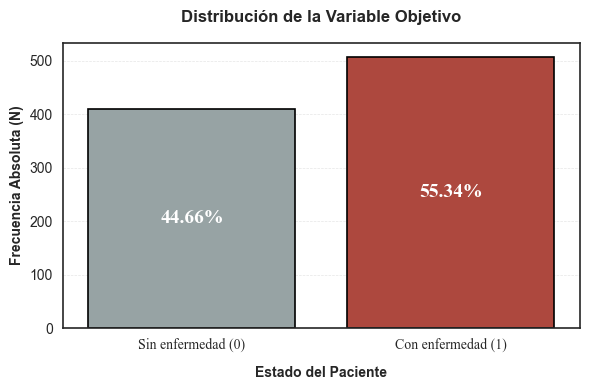

In [16]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, ax = plt.subplots(figsize=(6, 4))

colores_paper = ["#95a5a6", "#c0392b"]

ax = sns.barplot(
    x='HeartDisease', 
    y='count', 
    data=distribucion, 
    hue='HeartDisease',
    palette=colores_paper,
    edgecolor='black',
    linewidth=1.2,
    legend=False
)

total = distribucion['count'].sum()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.2f}%', 
                    (p.get_x() + p.get_width() / 2., height / 2.), 
                    ha='center', va='center', 
                    fontsize=14, 
                    color='white', 
                    fontweight='bold',
                    family='serif')

ax.set_title('Distribución de la Variable Objetivo', fontsize=12, pad=15, weight='bold')
ax.set_xlabel('Estado del Paciente', fontsize=10, weight='bold', labelpad=10)
ax.set_ylabel('Frecuencia Absoluta (N)', fontsize=10, weight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], family='serif')

def thousands_formatter(x, pos):
    return f'{int(x):,}'

ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

for spine in ax.spines.values():
    spine.set_visible(True)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
data = base64.b64encode(buf.getbuffer()).decode("ascii")

display(HTML(f"""
<div style="text-align: center; width: 100%;">
    <img src="data:image/png;base64,{data}">
</div>
"""))

### 2.3 Tipos de Datos y Valores Faltantes

La integridad del dataset constituye una condición fundamental para garantizar la validez de los resultados obtenidos en el modelo predictivo. En esta etapa, se evalúa la calidad de la información mediante la identificación de valores nulos y la verificación de la consistencia de los tipos de datos. Este diagnóstico permite distinguir entre variables con alta fidelidad informativa y aquellas cuya representatividad podría verse comprometida por la ausencia de datos.

Antes de avanzar hacia etapas más complejas del modelado, es necesario caracterizar la naturaleza técnica de los atributos. Esta clasificación establece la base del preprocesamiento, diferenciando entre variables numéricas y categóricas, lo cual define estrategias específicas de transformación, como escalamiento, codificación o tratamiento de valores faltantes. Esta separación es clave para estructurar un flujo de procesamiento coherente y evitar inconsistencias en las etapas posteriores del pipeline.

In [19]:
column_types = df.dtypes
type_groups = {}

for col_name, dtype in column_types.items():
    type_groups[str(dtype)] = type_groups.get(str(dtype), []) + [col_name]

resumen_tipos = pd.DataFrame([
    {
        'Tipo de Dato': t, 
        'Cantidad': len(cols), 
        'Variables': ", ".join(cols)
    }
    for t, cols in type_groups.items()
])

styled_types = resumen_tipos.style.hide(axis='index')

styled_types = styled_types.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px')]}
])

styled_types = styled_types.set_properties(subset=['Tipo de Dato'], **{'text-align': 'left'})
styled_types = styled_types.set_properties(subset=['Cantidad'], **{'text-align': 'center'})
styled_types = styled_types.set_properties(subset=['Variables'], **{'text-align': 'left'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_types.to_html() + "</div>"))

Tipo de Dato,Cantidad,Variables
int64,6,"Age, RestingBP, Cholesterol, FastingBS, MaxHR, HeartDisease"
object,5,"Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope"
float64,1,Oldpeak


El dataset presenta una composición mixta, con predominio de variables numéricas (principalmente de tipo entero) que representan mediciones clínicas, y variables categóricas codificadas como texto que describen características del paciente, como sexo, tipo de dolor torácico o resultados de exámenes.

Esta diversidad en la naturaleza de los atributos confirma la necesidad de estructurar un flujo de preprocesamiento capaz de aplicar transformaciones diferenciadas según el tipo de variable. 

### 2.4 Mapa de Densidad de Información (Missingness Map)

La construcción de un *missingness map* permite visualizar de manera estructurada la distribución de valores faltantes a lo largo del dataset, facilitando la identificación de patrones no aleatorios de ausencia de información. Este análisis es clave para determinar si los datos faltantes responden a un mecanismo sistemático (y no completamente al azar), lo cual impacta directamente las decisiones de imputación y la validez de las inferencias del modelo. Además, proporciona una visión global de la calidad del dataset antes de avanzar hacia etapas más complejas del preprocesamiento.

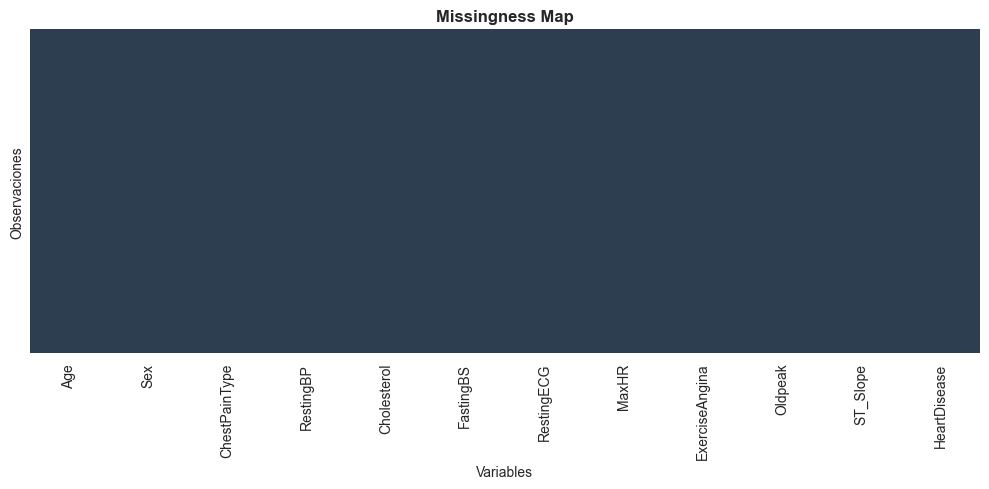

In [29]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=["#2c3e50", "#e74c3c"]  
)

plt.title("Missingness Map", fontsize=12, weight='bold')
plt.xlabel("Variables")
plt.ylabel("Observaciones")

plt.tight_layout()
plt.show()

El *missingness map* evidencia la **ausencia total de valores faltantes** en el dataset, lo cual indica una alta integridad y completitud de la información disponible. Este resultado elimina la necesidad de aplicar técnicas de imputación, simplificando el proceso de preprocesamiento y reduciendo una fuente potencial de sesgo en el modelado.


### 2.4 Análisis Univariado de Variables Cuantitativas

#### 2.4.1 Distribución y Detección de Valores Atípicos

En primer lugar, se generarán diagramas de caja y bigote (*boxplots*) para las variables numéricas, con el fin de analizar su distribución, identificar posibles valores atípicos y evaluar la dispersión de los datos. Este enfoque permite detectar comportamientos extremos que podrían influir en el desempeño del modelo y orientar decisiones posteriores de preprocesamiento.

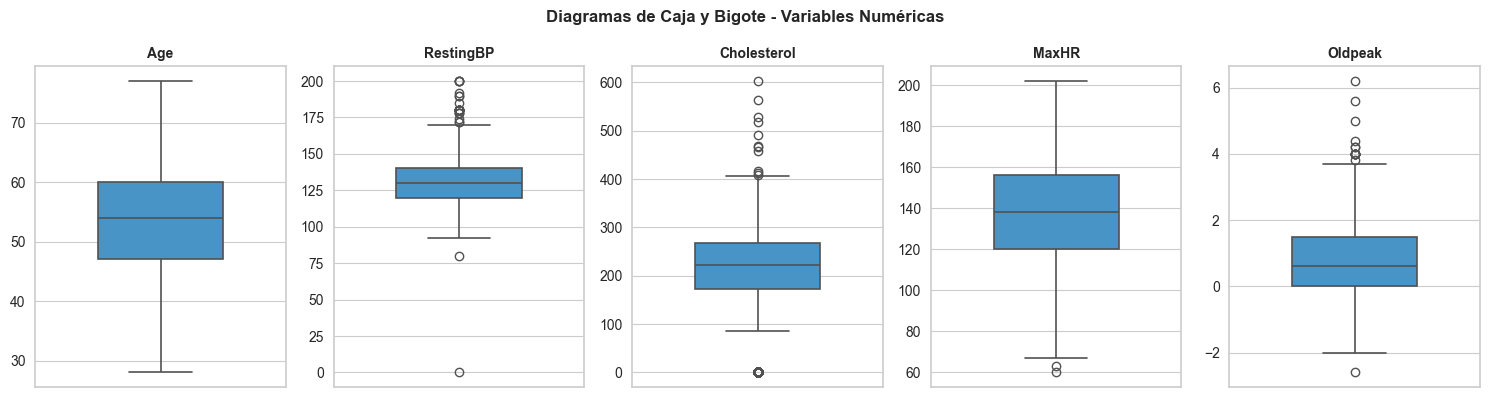

In [45]:
numeric_cols = [
    'Age', 'RestingBP', 'Cholesterol',
    'MaxHR', 'Oldpeak'
]

plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols), figsize=(15, 4))

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="#3498db",
        width=0.5,
        linewidth=1.2
    )
    
    axes[i].set_title(col, fontsize=10, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle('Diagramas de Caja y Bigote - Variables Numéricas', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


- **Age:** La distribución de la edad presenta una dispersión moderada, con una mediana cercana a los 55 años. No se observan valores atípicos extremos, lo cual indica una población relativamente homogénea en términos etarios dentro del rango observado.

- **RestingBP (Presión arterial en reposo):** Se evidencia una concentración principal entre valores normales, aunque aparecen algunos valores atípicos tanto altos como bajos. En particular, la presencia de valores extremadamente bajos podría indicar posibles inconsistencias o registros anómalos que deben ser considerados en el preprocesamiento.

- **Cholesterol:** Esta variable presenta una alta dispersión y una cantidad considerable de valores atípicos, especialmente hacia valores elevados. Esto sugiere la existencia de pacientes con niveles de colesterol significativamente altos, lo cual es clínicamente relevante, aunque también podría incluir valores extremos que requieran revisión.

- **MaxHR (Frecuencia cardíaca máxima):** La distribución es relativamente simétrica, con una dispersión moderada y pocos valores atípicos. Esto indica un comportamiento estable de la variable y una menor presencia de anomalías en comparación con otras variables.

- **Oldpeak:** Se observa una distribución asimétrica con presencia de múltiples valores atípicos en la parte superior. Esto sugiere una concentración de valores bajos con algunos casos extremos, lo cual puede ser relevante para el modelado, dado que esta variable está asociada a cambios en el segmento ST inducidos por ejercicio.

En conjunto, el análisis revela la presencia de valores atípicos en varias variables numéricas, lo cual debe ser considerado en etapas posteriores del pipeline.

#### 2.4.2 Análisis de Distribuciones

Complementando el análisis mediante diagramas de caja, se examina la distribución de las variables numéricas a través de histogramas y estimaciones de densidad. Este análisis permite identificar la forma de las distribuciones, evidenciando posibles asimetrías y concentraciones de valores.

En particular, la presencia de sesgos en ciertas variables sugiere que los datos no siguen una distribución normal, lo cual es relevante para la selección de modelos y técnicas de preprocesamiento. Estas características deben ser consideradas en etapas posteriores del pipeline para garantizar un modelado robusto.

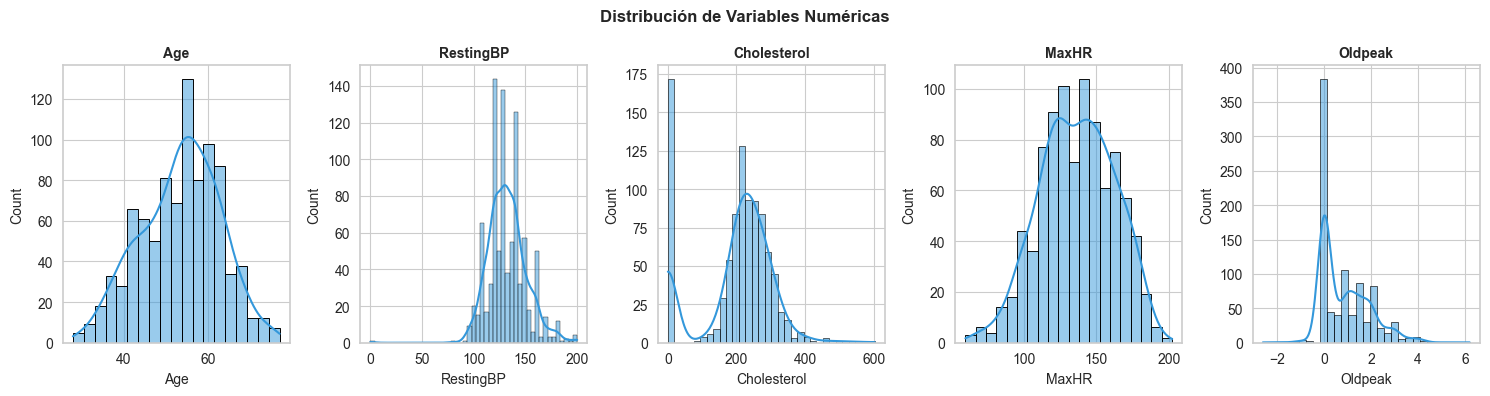

In [37]:
numeric_cols = [
    'Age', 'RestingBP', 'Cholesterol',
    'MaxHR', 'Oldpeak'
]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color="#3498db",
        edgecolor='black'
    )
    
    axes[i].set_title(col, fontsize=10, weight='bold')

plt.suptitle("Distribución de Variables Numéricas", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


- **Age:** La distribución es aproximadamente simétrica, con una ligera concentración alrededor de los 50–60 años. No se observa una asimetría marcada, lo que sugiere un comportamiento cercano a una distribución normal.

- **RestingBP (Presión arterial en reposo):** La distribución presenta cierta irregularidad, con picos concentrados en valores específicos, lo que podría indicar discretización o redondeo en los registros. Se observa además una ligera asimetría hacia la derecha, consistente con la presencia de valores elevados.

- **Cholesterol:** Se evidencia una distribución fuertemente asimétrica a la derecha, con una alta concentración de valores en rangos medios y una cola larga hacia valores elevados. La presencia de un pico cercano a valores muy bajos (incluso cercanos a cero) sugiere posibles registros atípicos o inconsistencias en los datos.

- **MaxHR (Frecuencia cardíaca máxima):** La variable presenta una distribución relativamente simétrica y suave, con forma cercana a una campana. Esto indica un comportamiento estable y bien distribuido en la población analizada.

- **Oldpeak:** Se observa una distribución altamente asimétrica a la derecha, con una gran concentración de valores cercanos a cero y una cola extendida hacia valores altos. Este patrón indica que la mayoría de los pacientes presentan valores bajos, con algunos casos extremos que generan la asimetría.

En conjunto, el análisis evidencia que no todas las variables siguen una distribución normal, destacándose especialmente la asimetría en variables como colesterol y oldpeak. Estas características deben ser consideradas en el modelado, particularmente en relación con la sensibilidad de ciertos algoritmos a la escala y distribución de los datos.

#### 2.4.3 Estadísticos Descriptivos

In [40]:
numeric_cols = [
    'Age', 'RestingBP', 'Cholesterol',
    'MaxHR', 'Oldpeak'
]

desc = df[numeric_cols].describe().T

desc['Skewness'] = df[numeric_cols].skew()

desc = desc[['mean', '50%', 'std', 'min', 'max', 'Skewness']]

desc.columns = [
    'Media', 'Mediana', 'Desv. Estándar',
    'Mínimo', 'Máximo', 'Asimetría'
]

desc = desc.reset_index().rename(columns={'index': 'Variable'})

styled_desc = desc.style.format({
    'Media': '{:.2f}',
    'Mediana': '{:.2f}',
    'Desv. Estándar': '{:.2f}',
    'Mínimo': '{:.2f}',
    'Máximo': '{:.2f}',
    'Asimetría': '{:.2f}'
}).hide(axis='index')

styled_desc = styled_desc.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'),
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'),
        ('background-color', '#f2f2f2'),
        ('color', 'black'),  
        ('font-weight', 'bold'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]}
])

styled_desc = styled_desc.set_properties(subset=['Variable'], **{
    'text-align': 'left',
    'font-weight': 'bold'
})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_desc.to_html() + "</div>"))

Variable,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Asimetría
Age,53.51,54.00,9.43,28.00,77.00,-0.20
RestingBP,132.40,130.00,18.51,0.00,200.00,0.18
Cholesterol,198.80,223.00,109.38,0.00,603.00,-0.61
MaxHR,136.81,138.00,25.46,60.00,202.00,-0.14
Oldpeak,0.89,0.60,1.07,-2.60,6.20,1.02


La tabla de estadísticos descriptivos permite cuantificar las características observadas previamente en los análisis gráficos, proporcionando una visión más precisa de la distribución de las variables numéricas.

En primer lugar, la comparación entre media y mediana evidencia distintos patrones de asimetría. Variables como **Cholesterol** presentan una media inferior a la mediana, lo que confirma una asimetría negativa, mientras que **Oldpeak** muestra una media superior a la mediana, indicando una fuerte asimetría positiva. En contraste, variables como **Age** y **MaxHR** exhiben valores cercanos entre ambas medidas, sugiriendo distribuciones relativamente simétricas.

En términos de dispersión, se observa que **Cholesterol** y **MaxHR** presentan las mayores desviaciones estándar, lo que indica una alta variabilidad en la población. Particularmente, el amplio rango de **Cholesterol** (0 a más de 600) sugiere la presencia de valores extremos o potencialmente inconsistentes, en línea con lo observado en los diagramas de caja.

Por otro lado, variables como **Age** presentan una dispersión más moderada, reflejando una población más homogénea en términos etarios. Asimismo, la variable **Oldpeak** destaca por su alta asimetría (1.02), lo cual confirma la concentración de valores bajos con presencia de casos extremos hacia valores elevados.

En conjunto, este análisis refuerza la evidencia de distribuciones no normales y la presencia de posibles valores atípicos en varias variables.

### 2.5 Análisis Univariado de Variables Cualitativas

#### 2.5.1 Distribución de Frecuencias

En primer lugar, se analiza la distribución de las variables categóricas mediante diagramas de barras (*countplots*), los cuales permiten visualizar la frecuencia de cada categoría dentro del dataset. Este análisis es fundamental para identificar posibles desbalances entre niveles y evaluar la representatividad de cada categoría, lo cual puede influir en el comportamiento del modelo durante el entrenamiento.

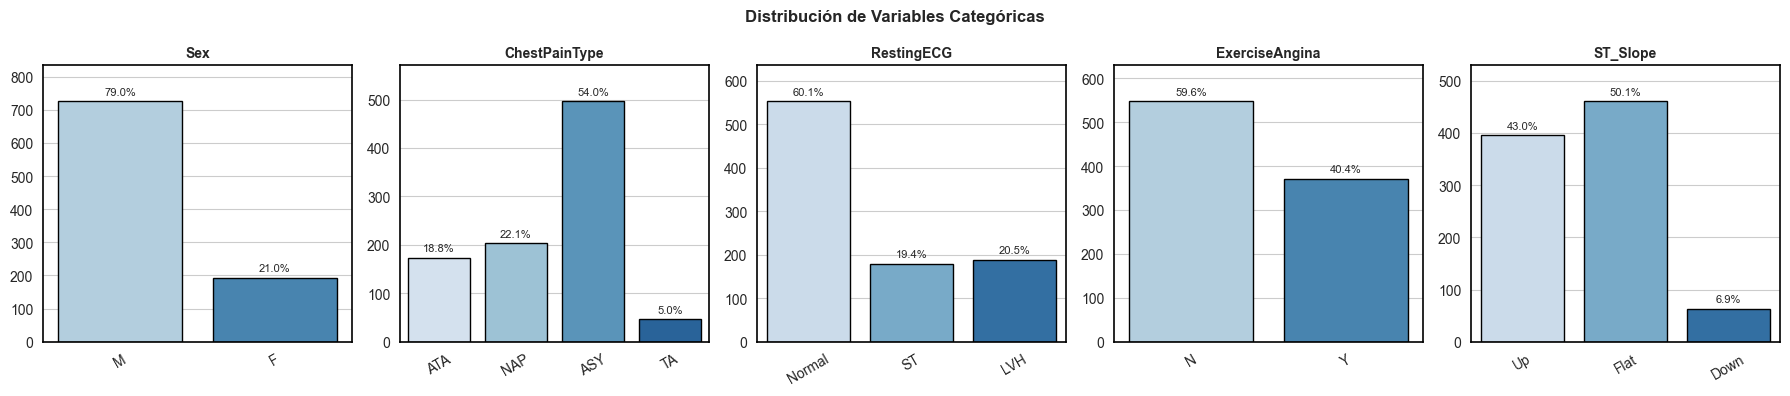

In [48]:
categorical_cols = [
    'Sex', 'ChestPainType', 'RestingECG',
    'ExerciseAngina', 'ST_Slope'
]

plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))

for i, col in enumerate(categorical_cols):
    
    ax = sns.countplot(
        x=col,
        data=df,
        hue=col,
        palette="Blues",
        edgecolor='black',
        ax=axes[i],
        legend=False
    )
    
    total = len(df)
    max_height = 0
    
    for p in ax.patches:
        if p.get_height() > max_height:
            max_height = p.get_height()
    
    ax.set_ylim(0, max_height * 1.15)
    
    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total) * 100
        
        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width()/2, height + max_height * 0.02),  
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.2)

plt.suptitle('Distribución de Variables Categóricas', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


- **Sex:** Se observa un claro predominio de pacientes masculinos (~79%) frente a femeninos (~21%). Este desbalance podría influir en el modelo si existen diferencias en la prevalencia de la enfermedad según el sexo, por lo que esta variable podría tener un impacto relevante en la predicción.

- **ChestPainType:** La categoría **ASY (asintomático)** es claramente dominante (~54%), seguida por NAP y ATA, mientras que TA tiene una representación mínima (~5%). Esta distribución sugiere que la ausencia de síntomas aparentes es común en la muestra, lo cual es clínicamente relevante y potencialmente altamente discriminante.

- **RestingECG:** La categoría **Normal** concentra la mayoría de los casos (~60%), mientras que ST y LVH tienen menor representación. Esto indica que, a pesar de tratarse de un dataset relacionado con enfermedad cardíaca, muchos pacientes presentan electrocardiogramas en reposo sin alteraciones evidentes.

- **ExerciseAngina:** Se observa una distribución relativamente balanceada, con una ligera predominancia de pacientes sin angina inducida por ejercicio (~60%) frente a aquellos que sí la presentan (~40%). Esta variable podría ser relevante para el modelo, dado que no presenta un desbalance extremo.

- **ST_Slope:** La categoría **Flat** es la más frecuente (~50%), seguida de Up (~43%), mientras que Down tiene una presencia muy reducida (~7%). Este comportamiento sugiere que ciertos patrones del segmento ST son más comunes en la muestra y podrían estar asociados a condiciones específicas del corazón.

#### 2.5.2 Análisis Porcentual de las Categorías

Luego, para complementar el análisis visual mediante diagramas de barras, se procede a cuantificar la distribución de cada categoría en términos porcentuales. Este enfoque permite obtener una medida más precisa de la representatividad de cada nivel, facilitando la comparación entre variables y la identificación de posibles desbalances internos.

El análisis porcentual proporciona una base más robusta para interpretar la importancia relativa de cada categoría, especialmente en variables con múltiples niveles, donde las diferencias de frecuencia pueden no ser evidentes únicamente a partir de los gráficos.


In [50]:
categorical_cols = [
    'Sex', 'ChestPainType', 'RestingECG',
    'ExerciseAngina', 'ST_Slope'
]

summary = []

for col in categorical_cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    for category in counts.index:
        summary.append({
            "Variable": col,
            "Categoría": category,
            "Frecuencia (N)": counts[category],
            "Proporción (%)": percentages[category]
        })

summary_df = pd.DataFrame(summary)

styled = summary_df.style.format({
    'Frecuencia (N)': '{:,.0f}',
    'Proporción (%)': '{:.2f}%'
}).hide(axis='index')

styled = styled.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'),
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'),
        ('background-color', '#f2f2f2'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]}
])

styled = styled.set_properties(subset=['Variable', 'Categoría'], **{
    'text-align': 'left',
    'font-weight': 'bold'
})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled.to_html() + "</div>"))

Variable,Categoría,Frecuencia (N),Proporción (%)
Sex,M,725,78.98%
Sex,F,193,21.02%
ChestPainType,ASY,496,54.03%
ChestPainType,NAP,203,22.11%
ChestPainType,ATA,173,18.85%
ChestPainType,TA,46,5.01%
RestingECG,Normal,552,60.13%
RestingECG,LVH,188,20.48%
RestingECG,ST,178,19.39%
ExerciseAngina,N,547,59.59%


En la variable **Sex**, se evidencia un claro predominio de pacientes masculinos (78.98%) frente a femeninos (21.02%), lo que indica un desbalance significativo que podría influir en el aprendizaje del modelo si el sexo está asociado al riesgo de enfermedad cardíaca.

En cuanto a **ChestPainType**, la categoría **ASY (asintomático)** concentra más de la mitad de los casos (54.03%), seguida por NAP (22.11%) y ATA (18.85%), mientras que TA presenta una representación marginal (5.01%). Este comportamiento sugiere que una gran proporción de pacientes no presenta síntomas típicos, lo cual resulta clínicamente relevante y potencialmente discriminante.

Para **RestingECG**, la mayoría de los registros corresponden a resultados normales (60.13%), con una distribución relativamente equilibrada entre LVH (20.48%) y ST (19.39%). Esto indica que las alteraciones en el electrocardiograma en reposo no son predominantes en la muestra.

La variable **ExerciseAngina** presenta una distribución moderadamente balanceada, con un 59.59% de pacientes sin angina inducida por ejercicio frente a un 40.41% que sí la presentan, lo que sugiere que esta variable podría aportar información relevante al modelo sin estar fuertemente sesgada.

Finalmente, en **ST_Slope**, se observa que la categoría **Flat** es la más frecuente (50.11%), seguida de Up (43.03%), mientras que Down tiene una presencia considerablemente menor (6.86%). Esta baja representación podría limitar el aprendizaje del modelo para esta categoría específica.


#### 2.5.3 Evaluación de Cardinalidad y Representatividad de Categorías

Con el fin de caracterizar la estructura de las variables categóricas, se evalúa la cardinalidad de cada atributo, es decir, el número de niveles presentes en cada variable. Este análisis permite identificar la complejidad de los datos categóricos y anticipar posibles implicaciones en etapas posteriores del modelado.

In [53]:
categorical_cols = [
    'Sex', 'ChestPainType', 'RestingECG',
    'ExerciseAngina', 'ST_Slope'
]

cardinality = pd.DataFrame({
    "Variable": categorical_cols,
    "N° Categorías": [df[col].nunique() for col in categorical_cols]
})

styled_card = cardinality.style.hide(axis='index')

styled_card = styled_card.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'),
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'),
        ('background-color', '#f2f2f2'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]}
])

styled_card = styled_card.set_properties(subset=['Variable'], **{
    'text-align': 'left',
    'font-weight': 'bold'
})


display(HTML("<div style='text-align: center; width: 100%;'>" + styled_card.to_html() + "</div>"))

Variable,N° Categorías
Sex,2
ChestPainType,4
RestingECG,3
ExerciseAngina,2
ST_Slope,3


El análisis de la cardinalidad muestra que todas las variables categóricas presentan un número reducido de niveles, oscilando entre 2 y 4 categorías. Esta baja cardinalidad simplifica significativamente el tratamiento de los datos, ya que evita la generación de espacios de características de alta dimensión durante la codificación.

En particular, variables binarias como **Sex** y **ExerciseAngina** presentan únicamente dos niveles, lo cual facilita su representación al modelar. Por otro lado, variables como **ChestPainType**, **RestingECG** y **ST_Slope**, aunque poseen más categorías, mantienen una estructura compacta y manejable.

Adicionalmente, se analizan las categorías con baja representación dentro de cada variable categórica, con el objetivo de identificar niveles que podrían tener un impacto limitado en el proceso de aprendizaje del modelo.

En este análisis, se define como criterio práctico considerar categorías poco representativas aquellas cuya proporción es inferior al 10%. 

La identificación de estas categorías resulta relevante, ya que niveles con baja representación pueden introducir ruido, aumentar la varianza del modelo o generar dificultades en la generalización hacia nuevos datos.

In [54]:
rare_summary = []

for col in categorical_cols:
    freq = df[col].value_counts(normalize=True) * 100
    rare = freq[freq < 10]  
    
    for category in rare.index:
        rare_summary.append({
            "Variable": col,
            "Categoría": category,
            "Proporción (%)": freq[category]
        })

rare_df = pd.DataFrame(rare_summary)

styled_rare = rare_df.style.format({
    'Proporción (%)': '{:.2f}%'
}).hide(axis='index')

styled_rare = styled_rare.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'),
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'),
        ('background-color', '#f2f2f2'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black'),
        ('padding', '10px')
    ]}
])

styled_rare = styled_rare.set_properties(subset=['Variable', 'Categoría'], **{
    'text-align': 'left',
    'font-weight': 'bold'
})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_rare.to_html() + "</div>"))

Variable,Categoría,Proporción (%)
ChestPainType,TA,5.01%
ST_Slope,Down,6.86%


El análisis identifica dos categorías con baja representación dentro del dataset: **TA** en la variable *ChestPainType* (5.01%) y **Down** en *ST_Slope* (6.86%).

Estas proporciones indican que dichos niveles están presentes en una fracción reducida de los datos, lo cual podría limitar la capacidad del modelo para aprender patrones asociados a estas categorías de manera robusta. En particular, la escasez de observaciones puede dificultar la estimación de relaciones significativas durante el entrenamiento.

No obstante, dado que el número de variables es reducido y la presencia de estas categorías no es completamente marginal, no se justifica su eliminación en esta etapa. En su lugar, se conservarán para el modelado, permitiendo que el algoritmo determine su relevancia en función de su contribución al desempeño predictivo.

### 2.6 Análisis Bivariado

#### 2.6.1  Relación entre Variables Categóricas y la Variable Objetivo
El análisis bivariado entre variables categóricas y la variable objetivo permite evaluar la capacidad discriminante de cada atributo en relación con la presencia de enfermedad cardíaca. A diferencia del análisis univariado, este enfoque examina cómo se distribuyen las categorías dentro de cada clase, identificando patrones diferenciales que pueden ser útiles para el modelo.

Para ello, se analizan las proporciones de cada categoría condicionadas a la variable objetivo, lo cual permite observar si ciertos niveles están asociados con una mayor o menor prevalencia de la enfermedad.

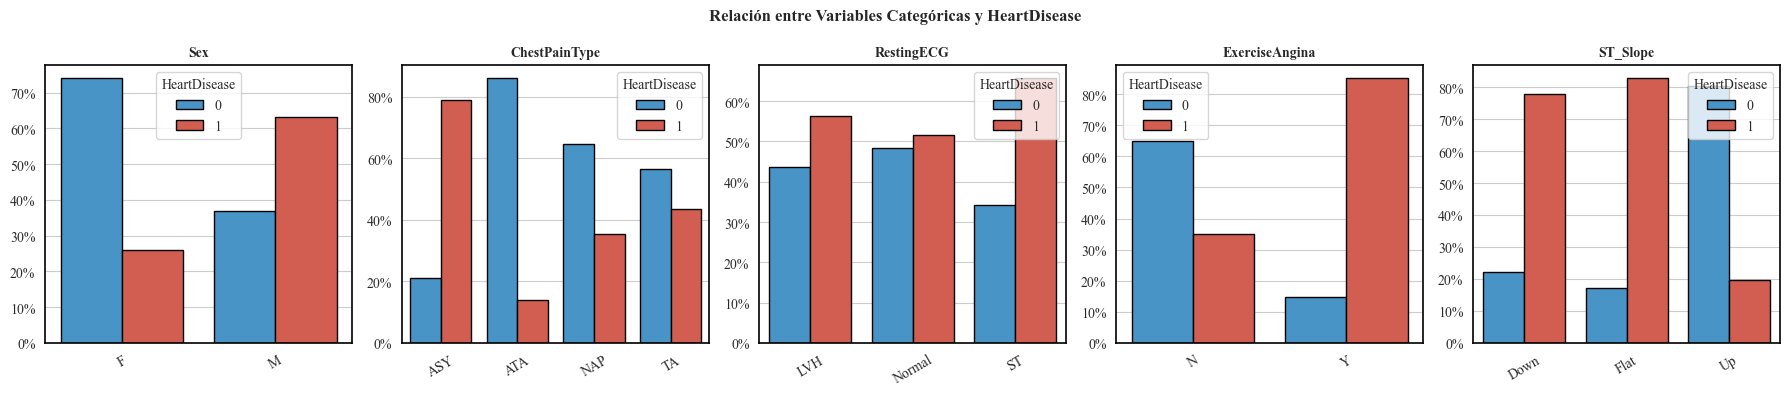

In [56]:
categorical_cols = [
    'Sex', 'ChestPainType', 'RestingECG',
    'ExerciseAngina', 'ST_Slope'
]

plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))

for i, col in enumerate(categorical_cols):
    
    prop_df = (
        df.groupby(col)['HeartDisease']
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    
    ax = sns.barplot(
        data=prop_df,
        x=col,
        y="proportion",
        hue="HeartDisease",
        palette=["#3498db", "#e74c3c"],
        edgecolor='black',
        ax=axes[i]
    )
    
    axes[i].yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
    
    axes[i].set_title(col, fontsize=10, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    axes[i].tick_params(axis='x', rotation=30)
    
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

plt.suptitle('Relación entre Variables Categóricas y HeartDisease', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()



- **Sex:** Se observa una diferencia marcada entre las categorías. Mientras que las mujeres presentan una menor proporción de enfermedad cardíaca (≈25%), los hombres muestran una prevalencia considerablemente mayor (≈65%). Esto sugiere que el sexo es una variable altamente discriminante en el dataset.

- **ChestPainType:** Esta variable presenta uno de los patrones más claros de separación. La categoría **ASY** (asintomático) muestra una alta proporción de pacientes con enfermedad (~80%), mientras que **ATA** presenta una proporción significativamente baja (~10–15%). Las categorías **NAP** y **TA** muestran comportamientos intermedios. Este contraste indica un fuerte poder predictivo de esta variable.

- **RestingECG:** Las diferencias entre categorías son menos pronunciadas. Aunque **ST** presenta una mayor proporción de enfermedad cardíaca en comparación con **Normal** y **LVH**, existe un solapamiento considerable entre las clases. Esto sugiere que esta variable tiene un poder discriminante limitado.

- **ExerciseAngina:** Se observa una separación clara entre las categorías. Los pacientes con angina inducida por ejercicio (**Y**) presentan una alta prevalencia de enfermedad (~80%), mientras que aquellos sin angina (**N**) tienen una proporción significativamente menor (~35%). Esta variable muestra un fuerte potencial predictivo.

- **ST_Slope:** También presenta una clara diferenciación. Las categorías **Flat** y **Down** están fuertemente asociadas con enfermedad cardíaca (≈80%), mientras que **Up** muestra una proporción mucho menor (~20%). Esto indica que la pendiente del segmento ST es un atributo altamente relevante para la clasificación.

En conjunto, se identifican variables con alto poder discriminante (**ChestPainType, ExerciseAngina, ST_Slope y Sex**), mientras que otras como **RestingECG** presentan una menor capacidad para separar las clases. Estos resultados sugieren que el modelo podrá apoyarse significativamente en ciertas variables categóricas para mejorar su desempeño predictivo.

#### 2.6.2 Relación entre Variables Numéricas y la Variable Objetivo

El análisis bivariado de las variables numéricas permite evaluar cómo se comportan los atributos continuos en función de la variable objetivo. A través de este enfoque, se comparan las distribuciones de cada variable entre pacientes con y sin enfermedad cardíaca, con el fin de identificar diferencias en tendencia central, dispersión y presencia de valores extremos.

Este análisis permite determinar si ciertas variables presentan patrones diferenciados entre las clases, lo cual es indicativo de su potencial capacidad discriminante en el contexto del modelado predictivo.

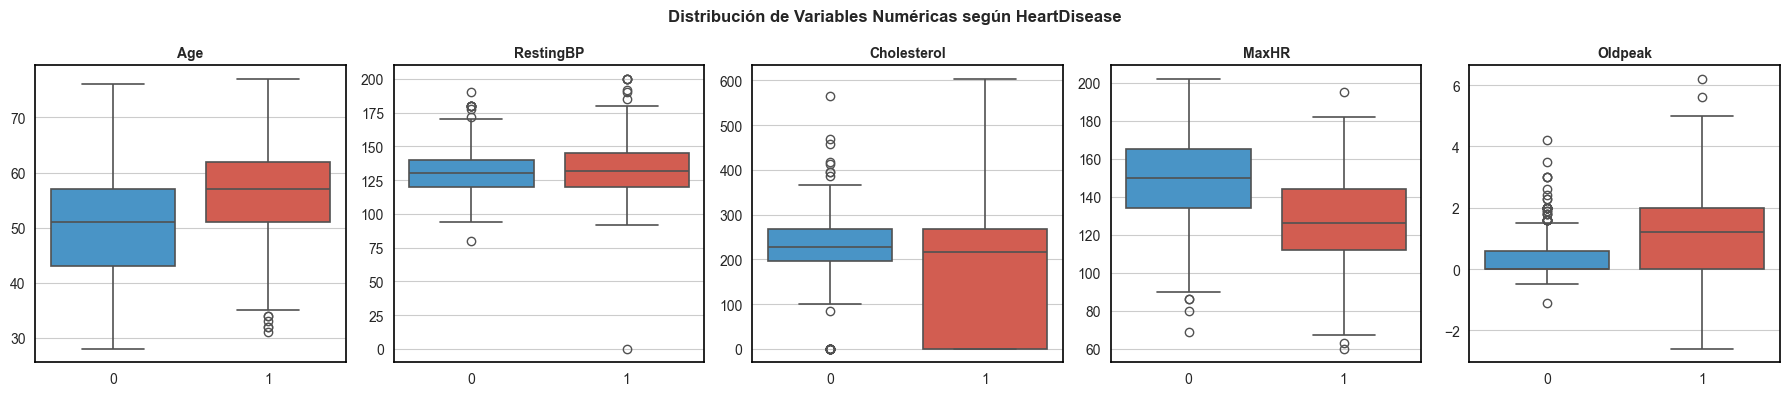

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'Age', 'RestingBP', 'Cholesterol',
    'MaxHR', 'Oldpeak'
]

plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))

for i, col in enumerate(numeric_cols):
    
    ax = sns.boxplot(
        x='HeartDisease',
        y=col,
        data=df,
        hue='HeartDisease',
        palette=["#3498db", "#e74c3c"],
        linewidth=1.2,
        ax=axes[i],
        legend=False
    )
    
    axes[i].set_title(col, fontsize=10, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.2)

plt.suptitle('Distribución de Variables Numéricas según HeartDisease', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


- **Age:** Se observa que los pacientes con enfermedad cardíaca presentan una mediana de edad mayor en comparación con aquellos sin la condición. Esto sugiere que la edad está positivamente asociada con la presencia de enfermedad, lo cual es consistente con el conocimiento clínico.

- **RestingBP (Presión arterial en reposo):** No se evidencian diferencias marcadas entre las distribuciones de ambas clases. Las medianas son similares y existe un alto grado de solapamiento, lo que indica un bajo poder discriminante de esta variable.

- **Cholesterol:** Se observa una alta dispersión en ambas clases, con presencia de valores extremos. Aunque los pacientes con enfermedad parecen tener una mayor variabilidad, las distribuciones presentan un solapamiento considerable, lo que limita su capacidad discriminante.

- **MaxHR (Frecuencia cardíaca máxima):** Se identifica una diferencia clara entre las clases. Los pacientes sin enfermedad presentan valores más altos de frecuencia cardíaca máxima, mientras que aquellos con enfermedad tienden a valores más bajos. Esta variable muestra un buen potencial discriminante.

- **Oldpeak:** Se observa una diferencia significativa entre las clases. Los pacientes con enfermedad presentan valores más altos y mayor dispersión, mientras que aquellos sin enfermedad se concentran cerca de valores bajos. Esta variable destaca como una de las más discriminantes.

En conjunto, se identifican variables con alto poder discriminante como **Age, MaxHR y Oldpeak**, mientras que otras como **RestingBP y Cholesterol** presentan una menor capacidad para diferenciar entre las clases. Estos resultados refuerzan la importancia de un enfoque multivariable en el modelado, donde la combinación de atributos permitirá capturar patrones más complejos.

Adicionalmente, se incluyen estimaciones de densidad (KDE) como complemento visual, permitiendo observar la forma de las distribuciones y el grado de solapamiento entre clases, lo cual no es completamente capturado por los boxplots.

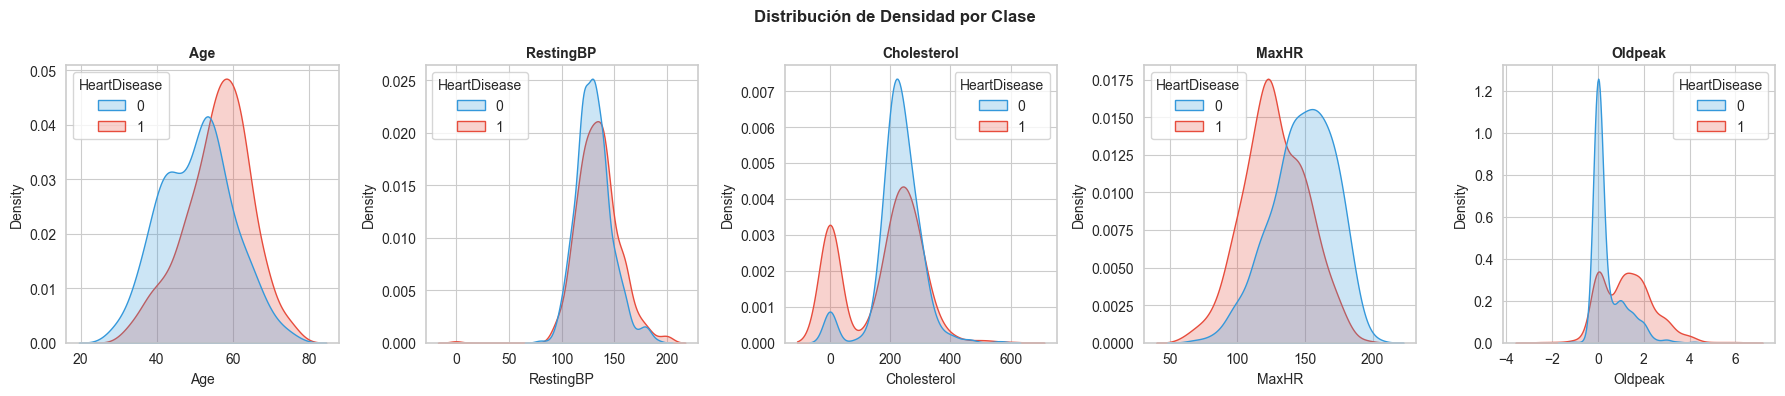

In [58]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))

for i, col in enumerate(numeric_cols):
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='HeartDisease',
        fill=True,
        common_norm=False,
        palette=["#3498db", "#e74c3c"],
        ax=axes[i]
    )
    
    axes[i].set_title(col, fontsize=10, weight='bold')
    
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle('Distribución de Densidad por Clase', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

Las estimaciones de densidad (KDE) complementan el análisis realizado mediante diagramas de caja y bigote, permitiendo visualizar con mayor detalle la forma de las distribuciones y el grado de solapamiento entre las clases.

En general, los resultados confirman los patrones identificados previamente en los boxplots, evidenciando diferencias en la ubicación y dispersión de ciertas variables entre pacientes con y sin enfermedad cardíaca. En particular, variables como *MaxHR* y *Oldpeak* muestran una clara separación entre las curvas de densidad, lo cual refuerza su capacidad discriminante, al presentar distribuciones desplazadas entre ambas clases.

Por otro lado, en variables como *RestingBP* y *Cholesterol* se observa un alto grado de solapamiento entre las densidades, lo cual coincide con lo observado en los diagramas de caja y sugiere una menor utilidad individual para la discriminación entre clases.

Asimismo, la visualización mediante KDE permite identificar características adicionales como asimetrías y posibles multimodalidades, especialmente en variables como *Cholesterol* y *Oldpeak*, ofreciendo otro punto de vista sobre la estructura de los datos.


## 3. Preprocesamiento